# 第 10 章 · 卷积

[章节网页](../ch10.html)

## 运行内容

- 运行 2D 卷积
- 输出卷积表
- 绘制特征图

## 0. 环境与数据

In [1]:
# 准备运行时：本 notebook 内嵌所需源码和数据，不依赖在线封装文件。
import importlib.util
import subprocess
import sys
from pathlib import Path

INLINE_RUNTIME_FILES = {
  "labs/ch10/vision.py": "\"\"\"Chapter 10 vision demos — pedagogical API.\"\"\"\n\nfrom __future__ import annotations\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom scipy.signal import correlate2d\n\nIMG = np.arange(16, dtype=float).reshape(4, 4)\nKERNEL = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]], dtype=float)\n\n\ndef conv2d_valid(x: np.ndarray, k: np.ndarray) -> np.ndarray:\n    return correlate2d(x, k, mode=\"valid\")\n\n\ndef conv_demo() -> None:\n    feat = conv2d_valid(IMG, KERNEL)\n    pooled = feat.max()\n    print(\"4x4 input → 2x2 conv特征:\")\n    print(feat.astype(int))\n    print(f\"MaxPool → {pooled:.0f}\")\n\n\ndef conv_output_table() -> pd.DataFrame:\n    feat = conv2d_valid(IMG, KERNEL)\n    rows = []\n    for i in range(feat.shape[0]):\n        for j in range(feat.shape[1]):\n            patch = IMG[i : i + KERNEL.shape[0], j : j + KERNEL.shape[1]]\n            rows.append(\n                {\n                    \"输出位置\": f\"({i},{j})\",\n                    \"输入窗口\": patch.astype(int).tolist(),\n                    \"卷积值\": int(feat[i, j]),\n                }\n            )\n    return pd.DataFrame(rows)\n\n\ndef plot_conv() -> None:\n    feat = conv2d_valid(IMG, KERNEL)\n    fig, axes = plt.subplots(1, 3, figsize=(9, 3))\n    axes[0].imshow(IMG, cmap=\"gray\")\n    axes[0].set_title(\"4x4 input\")\n    axes[1].imshow(feat, cmap=\"viridis\")\n    axes[1].set_title(\"2x2 conv\")\n    axes[2].bar([\"max\"], [feat.max()], color=\"#0d6b62\")\n    axes[2].set_title(f\"MaxPool={feat.max():.0f}\")\n    for ax in axes[:2]:\n        ax.axis(\"off\")\n    plt.suptitle(\"CNN pipeline\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef codelens_conv() -> list:\n    from common.codelens import Frame\n\n    kh, kw = KERNEL.shape\n    h, w = IMG.shape\n    frames: list = []\n    step = 0\n    for i in range(h - kh + 1):\n        for j in range(w - kw + 1):\n            patch = IMG[i : i + kh, j : j + kw]\n            val = float((patch * KERNEL).sum())\n            frames.append(\n                Frame(\n                    step,\n                    f\"out[{i},{j}] = sum(patch*K)\",\n                    f\"窗口 ({i},{j}) 卷积\",\n                    {\"patch_pos\": (i, j, kh, kw), \"out_val\": val, \"grid\": IMG.copy()},\n                )\n            )\n            step += 1\n    return frames\n\n\ndef animate_conv_slide() -> None:\n    from common.viz_anim import animate_grid_highlight\n\n    frames = codelens_conv()\n    snaps = []\n    for f in frames:\n        i, j, kh, kw = f.state[\"patch_pos\"]\n        snaps.append(\n            {\n                \"step\": f.step,\n                \"grid\": f.state[\"grid\"],\n                \"patch\": (i, j, kh, kw),\n                \"out_val\": f.state[\"out_val\"],\n                \"action\": f.narrative,\n            }\n        )\n    animate_grid_highlight(snaps, title=\"Conv2d sliding window\", fps=1.5)\n\n\ndef vit_patchify() -> None:\n    patches = IMG.reshape(2, 2, 2, 2).transpose(0, 2, 1, 3).reshape(4, 4)\n    print(\"4 个 2×2 patch → token:\")\n    for i, p in enumerate(patches):\n        print(f\"  P{i+1}: {p.astype(int).tolist()}\")\n\n\ndef plot_patches() -> None:\n    fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))\n    axes[0].imshow(IMG, cmap=\"gray\")\n    axes[0].set_title(\"input\")\n    patches = IMG.reshape(2, 2, 2, 2).transpose(0, 2, 1, 3)\n    for i in range(4):\n        axes[i + 1].imshow(patches[i // 2, i % 2], cmap=\"gray\")\n        axes[i + 1].set_title(f\"P{i+1}\")\n    for ax in axes:\n        ax.axis(\"off\")\n    plt.suptitle(\"ViT patchify\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef mae_demo() -> None:\n    mask = np.array([0, 1, 1, 1])\n    print(\"MAE 掩码 75%: 可见 patch 索引\", np.where(mask == 0)[0].tolist())\n    print(\"Encoder 只看 25% token → Decoder 重构全图 MSE\")\n\n\ndef plot_mae_mask() -> None:\n    mask = np.array([0, 1, 1, 1])\n    fig, ax = plt.subplots(figsize=(4, 4))\n    grid = np.arange(4).reshape(2, 2)\n    show = np.where(mask.reshape(2, 2) == 0, grid, np.nan)\n    ax.imshow(show, cmap=\"Greens\")\n    ax.set_title(\"MAE: 75% masked\")\n    ax.axis(\"off\")\n    plt.tight_layout()\n    plt.show()\n\n\ndef clip_infonce() -> None:\n    v_i = np.array([0.9, 0.1, 0.0])\n    v_t_pos = np.array([0.85, 0.12, 0.05])\n    v_t_neg = np.array([0.1, 0.2, 0.9])\n    cos = lambda a, b: float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))\n    print(f\"正例 cos={cos(v_i, v_t_pos):.2f} (网页 0.91)\")\n    print(f\"负例 cos={cos(v_i, v_t_neg):.2f} (网页 0.08)\")\n\n\ndef plot_clip_cos() -> None:\n    labels = [\"pos pair\", \"neg pair\"]\n    vals = [0.91, 0.08]\n    fig, ax = plt.subplots()\n    ax.bar(labels, vals, color=[\"#0d6b62\", \"#e74c3c\"])\n    ax.set_ylim(0, 1)\n    ax.set_title(\"CLIP cosine similarity\")\n    plt.tight_layout()\n    plt.show()\n",
  "labs/common/campus_graph.json": "{\n  \"goal\": \"c1\",\n  \"start\": \"x\",\n  \"nodes\": {\n    \"x\": { \"name\": \"校门口\", \"h\": 7 },\n    \"c2\": { \"name\": \"超市\", \"h\": 1 },\n    \"j\": { \"name\": \"教学楼\", \"h\": 4 },\n    \"s2\": { \"name\": \"实验楼\", \"h\": 4 },\n    \"s1\": { \"name\": \"食堂\", \"h\": 3 },\n    \"t\": { \"name\": \"图书馆\", \"h\": 2 },\n    \"c1\": { \"name\": \"操场\", \"h\": 0 }\n  },\n  \"edges\": [\n    { \"from\": \"x\", \"to\": \"c2\", \"cost\": 7 },\n    { \"from\": \"x\", \"to\": \"j\", \"cost\": 2 },\n    { \"from\": \"x\", \"to\": \"s1\", \"cost\": 2 },\n    { \"from\": \"j\", \"to\": \"s2\", \"cost\": 4 },\n    { \"from\": \"s2\", \"to\": \"s1\", \"cost\": 1 },\n    { \"from\": \"s1\", \"to\": \"t\", \"cost\": 3 },\n    { \"from\": \"s1\", \"to\": \"c1\", \"cost\": 6 },\n    { \"from\": \"t\", \"to\": \"c1\", \"cost\": 2 }\n  ],\n  \"expected\": {\n    \"dfs\": { \"path\": [\"x\", \"j\", \"s2\", \"s1\", \"c1\"], \"steps\": 4, \"cost\": 13 },\n    \"bfs\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"ucs\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 },\n    \"greedy\": { \"path\": [\"x\", \"s1\", \"c1\"], \"steps\": 2, \"cost\": 8 },\n    \"astar\": { \"path\": [\"x\", \"s1\", \"t\", \"c1\"], \"steps\": 3, \"cost\": 7 }\n  }\n}\n",
  "labs/common/ch6_kg.json": "{\n  \"nodes\": [\"鲁迅\", \"狂人日记\", \"呐喊\", \"文学周报社\", \"茅盾文学奖\", \"莫言\", \"蛙\", \"红高粱\", \"典藏\", \"电影\", \"金熊奖\"],\n  \"edges\": [\n    [\"鲁迅\", \"创作\", \"狂人日记\"],\n    [\"鲁迅\", \"创作\", \"呐喊\"],\n    [\"狂人日记\", \"发表于\", \"文学周报社\"],\n    [\"呐喊\", \"发表于\", \"文学周报社\"],\n    [\"狂人日记\", \"获得\", \"茅盾文学奖\"],\n    [\"莫言\", \"创作\", \"蛙\"],\n    [\"莫言\", \"创作\", \"红高粱\"],\n    [\"蛙\", \"获得\", \"茅盾文学奖\"],\n    [\"红高粱\", \"入选\", \"典藏\"],\n    [\"红高粱\", \"改编\", \"电影\"],\n    [\"电影\", \"获得\", \"金熊奖\"]\n  ],\n  \"query\": {\n    \"pattern\": [\"鲁迅\", \"创作\", \"?X\", \"?X\", \"发表于\", \"?Y\"],\n    \"answer_y\": \"文学周报社\"\n  },\n  \"path_scores\": {\n    \"蛙→茅盾文学奖\": 3,\n    \"红高粱→典藏\": 2,\n    \"红高粱→电影→金熊奖\": 3\n  }\n}\n",
  "labs/common/ch6_rules.json": "{\n  \"facts\": [\"人(苏格拉底)\"],\n  \"rules\": [\n    { \"id\": \"R1\", \"if\": [\"人(X)\"], \"then\": \"会死(X)\" },\n    { \"id\": \"R2\", \"if\": [\"会死(X)\"], \"then\": \"终有一死(X)\" }\n  ],\n  \"goal\": \"终有一死(苏格拉底)\"\n}\n",
  "labs/common/codelens.py": "\"\"\"CodeLens-style execution frames — print every variable change.\"\"\"\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass, field\nfrom typing import Any\n\n\n@dataclass\nclass Frame:\n    step: int\n    line: str\n    narrative: str\n    state: dict[str, Any] = field(default_factory=dict)\n\n    def print(self) -> None:\n        print(f\"── Step {self.step} ── {self.narrative}\")\n        print(f\"   执行: {self.line}\")\n        for k, v in self.state.items():\n            print(f\"   {k} = {v!r}\")\n\n\ndef print_frames(frames: list[Frame], start: int = 0, stop: int | None = None) -> None:\n    for f in frames[start:stop]:\n        f.print()\n        print()\n\n\ndef frames_to_table(frames: list[Frame], keys: list[str]) -> \"pd.DataFrame\":\n    import pandas as pd\n\n    rows = []\n    for f in frames:\n        row = {\"步\": f.step, \"说明\": f.narrative}\n        for k in keys:\n            row[k] = f.state.get(k, \"\")\n        rows.append(row)\n    return pd.DataFrame(rows)\n",
  "labs/common/luxun_bpe.json": "{\n  \"corpus_hint\": \"鲁迅 写 了 狂人 日记\",\n  \"initial_tokens\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日\", \"记\"],\n  \"merges\": [\n    { \"pair\": [\"日\", \"记\"], \"count\": 12, \"result\": \"日记\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂\", \"人\", \"日记\"] },\n    { \"pair\": [\"狂\", \"人\"], \"count\": 8, \"result\": \"狂人\", \"tokens_after\": [\"鲁\", \"迅\", \"写\", \"了\", \"狂人\", \"日记\"] },\n    { \"pair\": [\"鲁\", \"迅\"], \"count\": 6, \"result\": \"鲁迅\", \"tokens_after\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"] }\n  ],\n  \"final_tokens\": [\"鲁迅\", \"写\", \"了\", \"狂人\", \"日记\"]\n}\n",
  "labs/common/mpl_setup.py": "\"\"\"Matplotlib font setup for notebook figures.\"\"\"\n\nfrom __future__ import annotations\n\nimport logging\nimport warnings\nfrom pathlib import Path\n\nimport matplotlib as mpl\nimport matplotlib.font_manager as fm\n\n# Prefer one fixed CJK face in rendered site; keep local fallbacks for downloaded notebooks.\nCJK_FONT = \"Noto Sans CJK SC\"\n\n_FONT_PATHS = [\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc\",\n    \"/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc\",\n    \"/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc\",\n    \"/System/Library/Fonts/PingFang.ttc\",\n    \"/System/Library/Fonts/STHeiti Light.ttc\",\n    \"/Library/Fonts/Arial Unicode.ttf\",\n]\n\n_CJK_NAMES = [\n    CJK_FONT,\n    \"Noto Sans SC\",\n    \"Source Han Sans SC\",\n    \"PingFang SC\",\n    \"Heiti SC\",\n    \"STHeiti\",\n    \"Arial Unicode MS\",\n    \"WenQuanYi Micro Hei\",\n]\n\n_CONFIGURED = False\n\n\ndef _register_font_files() -> str | None:\n    registered: list[str] = []\n    for path in _FONT_PATHS:\n        p = Path(path)\n        if not p.is_file():\n            continue\n        try:\n            fm.fontManager.addfont(str(p))\n            prop = fm.FontProperties(fname=str(p))\n            name = prop.get_name()\n            if name and name not in registered:\n                registered.append(name)\n        except Exception:\n            continue\n    return registered[0] if registered else None\n\n\ndef _find_cjk_font() -> str | None:\n    from_file = _register_font_files()\n    available = {f.name for f in fm.fontManager.ttflist}\n    if CJK_FONT in available:\n        return CJK_FONT\n    if from_file:\n        return from_file\n    for name in _CJK_NAMES:\n        if name in available:\n            return name\n    return None\n\n\ndef configure_matplotlib() -> None:\n    \"\"\"Notebook 首个绘图 cell 前调用一次。\"\"\"\n    global _CONFIGURED\n    if _CONFIGURED:\n        return\n    _CONFIGURED = True\n\n    logging.getLogger(\"matplotlib.font_manager\").setLevel(logging.ERROR)\n    warnings.filterwarnings(\"ignore\", message=\".*Glyph.*missing from font.*\")\n    warnings.filterwarnings(\"ignore\", message=\".*findfont.*\")\n\n    name = _find_cjk_font()\n    if name:\n        mpl.rcParams[\"font.sans-serif\"] = [name, \"DejaVu Sans\", \"sans-serif\"]\n        mpl.rcParams[\"font.family\"] = \"sans-serif\"\n    else:\n        mpl.rcParams[\"font.sans-serif\"] = [\"DejaVu Sans\", \"sans-serif\"]\n    mpl.rcParams[\"axes.unicode_minus\"] = False\n    mpl.rcParams[\"figure.dpi\"] = 100\n    mpl.rcParams[\"mathtext.default\"] = \"regular\"\n\n\ndef ascii_plot(text: str) -> str:\n    \"\"\"把常见数学符号换成 DejaVu 可显示的 ASCII（用于轴标签/GIF）。\"\"\"\n    repl = {\n        \"α\": \"alpha\",\n        \"β\": \"beta\",\n        \"γ\": \"gamma\",\n        \"δ\": \"delta\",\n        \"ε\": \"eps\",\n        \"σ\": \"sigma\",\n        \"ŷ\": \"y_hat\",\n        \"₁\": \"1\",\n        \"₂\": \"2\",\n        \"₃\": \"3\",\n        \"→\": \"->\",\n    }\n    out = text\n    for k, v in repl.items():\n        out = out.replace(k, v)\n    return out\n",
  "labs/common/notebook_helpers.py": "\"\"\"Shared helpers for pedagogical notebooks.\"\"\"\n\nfrom __future__ import annotations\n\nimport textwrap\nfrom pathlib import Path\n\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\n\n# Keep helper plots aligned with the rendered notebook font.\nplt.rcParams.update(\n    {\n        \"figure.figsize\": (7.5, 4.2),\n        \"font.size\": 11,\n        \"axes.unicode_minus\": False,\n        \"font.family\": \"sans-serif\",\n        \"font.sans-serif\": [\"Noto Sans CJK SC\", \"DejaVu Sans\", \"sans-serif\"],\n    }\n)\n\n\ndef repo_root() -> Path:\n    cwd = Path.cwd()\n    if (cwd / \"labs\").exists():\n        return cwd\n    if (cwd.parent / \"labs\").exists():\n        return cwd.parent\n    return cwd\n\n\nBOOTSTRAP = textwrap.dedent(\n    \"\"\"\n    import sys\n    from pathlib import Path\n    ROOT = Path.cwd()\n    if not (ROOT / \"labs\").exists() and (ROOT.parent / \"labs\").exists():\n        ROOT = ROOT.parent\n    if str(ROOT) not in sys.path:\n        sys.path.insert(0, str(ROOT))\n    \"\"\"\n).strip()\n\n\ndef bootstrap_code(extra: str = \"\") -> str:\n    return BOOTSTRAP + (\"\\n\" + extra.strip() if extra.strip() else \"\")\n\n\ndef show_df(df: pd.DataFrame, title: str = \"\") -> None:\n    if title:\n        print(title)\n    print(df.to_string(index=False))\n\n\ndef plot_line_series(\n    xs: list,\n    ys: list,\n    *,\n    title: str,\n    xlabel: str = \"\",\n    ylabel: str = \"\",\n    markers: bool = True,\n) -> None:\n    fig, ax = plt.subplots()\n    ax.plot(xs, ys, marker=\"o\" if markers else None, linewidth=2)\n    ax.set_title(title)\n    if xlabel:\n        ax.set_xlabel(xlabel)\n    if ylabel:\n        ax.set_ylabel(ylabel)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n\n\ndef plot_scatter_labeled(\n    points: np.ndarray,\n    labels: np.ndarray | None,\n    *,\n    title: str,\n    label_names: dict[int, str] | None = None,\n) -> None:\n    fig, ax = plt.subplots()\n    if labels is None:\n        ax.scatter(points[:, 0], points[:, 1], s=60, c=\"#0d6b62\")\n    else:\n        for lab in np.unique(labels):\n            mask = labels == lab\n            name = (label_names or {}).get(int(lab), f\"类 {lab}\")\n            ax.scatter(points[mask, 0], points[mask, 1], s=60, label=name)\n        ax.legend()\n    ax.set_title(title)\n    ax.grid(True, alpha=0.3)\n    plt.tight_layout()\n    plt.show()\n"
}

ROOT = Path.cwd() / "_ai_thinking_labs_inline_runtime"
for rel, source in INLINE_RUNTIME_FILES.items():
    target = ROOT / rel
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text(source, encoding="utf-8")

missing = []
for module, package in [
    ("numpy", "numpy>=1.24"),
    ("pandas", "pandas>=2.0"),
    ("matplotlib", "matplotlib>=3.7"),
    ("scipy", "scipy>=1.10"),
    ("sklearn", "scikit-learn>=1.3"),
]:
    if importlib.util.find_spec(module) is None:
        missing.append(package)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "labs"))
sys.path.insert(0, str(ROOT / "labs" / "ch10"))
import matplotlib.pyplot as plt
from common.mpl_setup import configure_matplotlib
configure_matplotlib()
from IPython.display import display, Image
print("runtime ready:", ROOT)
from vision import *

runtime ready: /Users/zhesun/Desktop/Fudan/phd/vibe coding/notebooks/_ai_thinking_labs_inline_runtime


In [2]:
# 直接调用 scipy.signal.correlate2d 计算 valid 卷积。
from scipy.signal import correlate2d
feature = correlate2d(IMG, KERNEL, mode='valid')
print(feature.astype(int))

[[-6 -6]
 [-6 -6]]


In [3]:
# 输出每个窗口位置的卷积值表。
display(conv_output_table())

,输出位置,输入窗口,卷积值
0,"(0,0)","[[0, 1, 2], [4, 5, 6], [8, 9, 10]]",-6
1,"(0,1)","[[1, 2, 3], [5, 6, 7], [9, 10, 11]]",-6
2,"(1,0)","[[4, 5, 6], [8, 9, 10], [12, 13, 14]]",-6
3,"(1,1)","[[5, 6, 7], [9, 10, 11], [13, 14, 15]]",-6


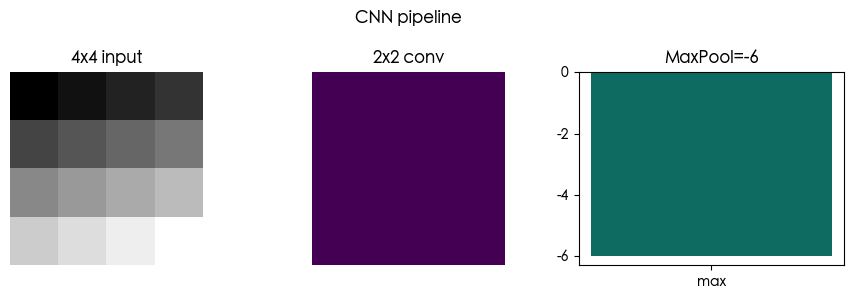

In [4]:
# 绘制输入、卷积输出和 MaxPool 结果。
plot_conv()